In [2]:
# Imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm  # OLS summary (p-values, confidence intervals)

In [3]:
import pandas as pd
import glob
import os

# 1. Setup the path where you extracted the files
# Put all your .csv files in a folder named 'data'
path = './data' 
all_files = glob.glob(os.path.join(path, "*.csv"))

# 2. List to hold dataframes
df_list = []

for filename in all_files:
    # Read the file
    df_temp = pd.read_csv(filename)
    
    # Extract the brand name from the file name (e.g., 'bmw.csv' -> 'bmw')
    brand_name = os.path.basename(filename).replace('.csv', '')
    df_temp['brand'] = brand_name
    
    df_list.append(df_temp)

# 3. Concatenate everything into one Master Dataframe
master_df = pd.concat(df_list, axis=0, ignore_index=True)

# 4. Save the Master File for your VS Code project
master_df.to_csv('master_car_listings.csv', index=False)

print(f"Master file created! Total observations: {len(master_df)}")
    
# Standardize column names
master_df.columns = master_df.columns.str.lower()
    
print(f" Load successful: {master_df.shape[0]} rows, {master_df.shape[1]} columns.")
display(master_df.head(30))

Master file created! Total observations: 118150
 Load successful: 118150 rows, 17 columns.


,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,brand,tax(£),fuel type,engine size,mileage2,fuel type2,engine size2,reference
0,A1,2017.0,12500,Manual,15735,Petrol,150.0,55.4,1.4,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A6,2016.0,16500,Automatic,36203,Diesel,20.0,64.2,2.0,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A1,2016.0,11000,Manual,29946,Petrol,30.0,55.4,1.4,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A4,2017.0,16800,Automatic,25952,Diesel,145.0,67.3,2.0,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A3,2019.0,17300,Manual,1998,Petrol,145.0,49.6,1.0,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,A1,2016.0,13900,Automatic,32260,Petrol,30.0,58.9,1.4,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,A6,2016.0,13250,Automatic,76788,Diesel,30.0,61.4,2.0,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,A4,2016.0,11750,Manual,75185,Diesel,20.0,70.6,2.0,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,A3,2015.0,10200,Manual,46112,Petrol,20.0,60.1,1.4,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,A1,2016.0,12000,Manual,22451,Petrol,30.0,55.4,1.4,audi,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your dataset
# df = pd.read_csv('BMW_sales_data_2010_2024.csv')

# 2. Create the histogram for the target variable (sales_volume)
plt.figure(figsize=(10, 6))
plt.hist(df['sales_volume'], bins=50, color='skyblue', edgecolor='black')

# 3. Add titles and labels (English as requested)
plt.title('Distribution of Sales Volume (BMW Dataset)')
plt.xlabel('Sales Volume')
plt.ylabel('Frequency (Number of observations)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 4. Save and show
plt.savefig('sales_volume_distribution.png')
plt.show()

# 5. Quick statistical check to see the variance
print("--- Statistical Summary of Sales Volume ---")
print(df['sales_volume'].describe())

NameError: name 'df' is not defined

<Figure size 1000x600 with 0 Axes>

### I sales volume sono sempre uguali perchè il tizio che ha generato il dataset ha usato una generazione random uniforme.

C:\Users\filip\AppData\Local\Temp\ipykernel_31176\2079181312.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x='region', y='sales_volume', palette='viridis')


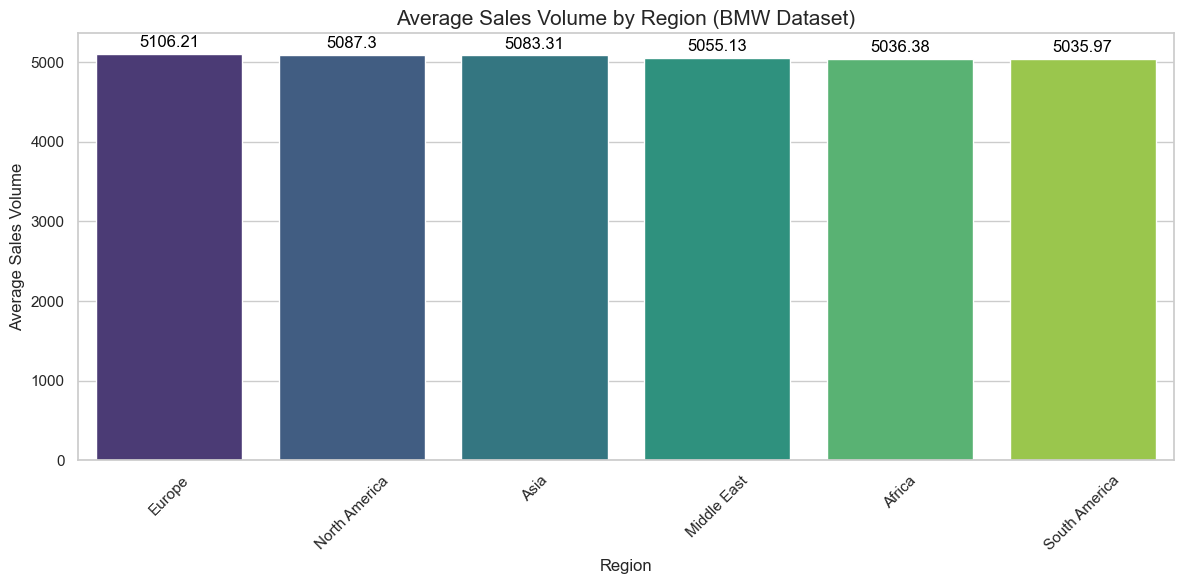

--- Average Sales Volume by Region ---
          region  sales_volume
0         Europe   5106.208063
1  North America   5087.298020
2           Asia   5083.306955
3    Middle East   5055.131972
4         Africa   5036.380952
5  South America   5035.973579


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
# df = pd.read_csv('BMW_sales_data_2010_2024.csv')

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 3. Calculate the mean sales volume per region
# This helps us see if certain regions perform better than others
region_sales = df.groupby('region')['sales_volume'].mean().sort_values(ascending=False).reset_index()

# 4. Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=region_sales, x='region', y='sales_volume', palette='viridis')

# 5. Add labels and title
plt.title('Average Sales Volume by Region (BMW Dataset)', fontsize=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Average Sales Volume', fontsize=12)
plt.xticks(rotation=45)

# 6. Show the exact values on top of the bars for better clarity
for index, row in region_sales.iterrows():
    plt.text(index, row.sales_volume + 50, round(row.sales_volume, 2), 
             color='black', ha="center", va="bottom")

plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

# 7. Statistical comparison
print("--- Average Sales Volume by Region ---")
print(region_sales)

C:\Users\filip\AppData\Local\Temp\ipykernel_31176\1252908750.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=color_analysis, x='color', y='sales_volume', palette='magma')


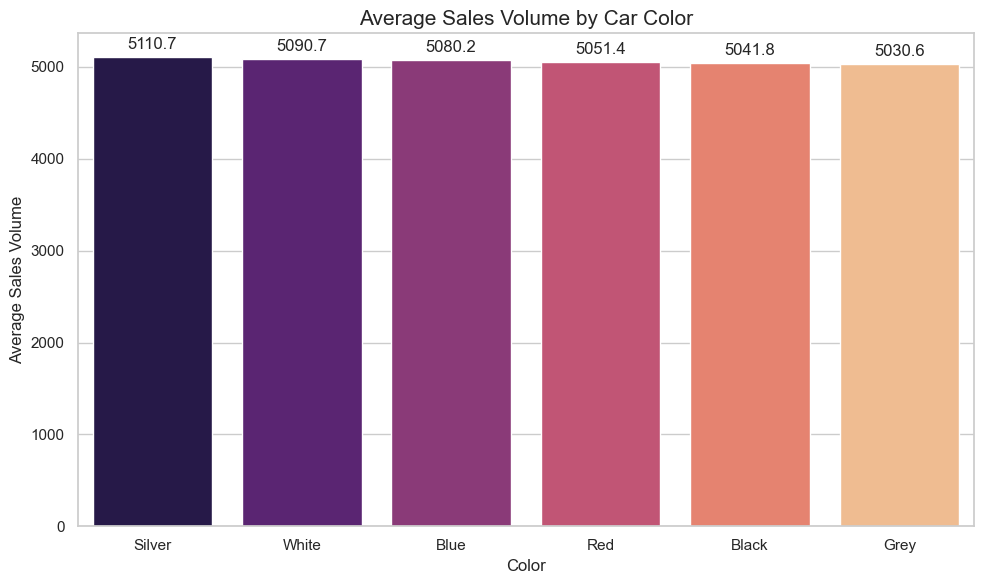

--- Average Sales Volume by Color ---
    color  sales_volume
0  Silver   5110.661317
1   White   5090.673651
2    Blue   5080.215565
3     Red   5051.421836
4   Black   5041.785688
5    Grey   5030.563129


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set visualization settings
sns.set_theme(style="whitegrid")

# 2. Group by 'color' and calculate the mean of 'sales_volume'
# This will show if certain colors are more "successful" in terms of volume
color_analysis = df.groupby('color')['sales_volume'].mean().sort_values(ascending=False).reset_index()

# 3. Create the bar chart
plt.figure(figsize=(10, 6))
bar_plot = sns.barplot(data=color_analysis, x='color', y='sales_volume', palette='magma')

# 4. Add titles and labels (in English as requested)
plt.title('Average Sales Volume by Car Color', fontsize=15)
plt.xlabel('Color', fontsize=12)
plt.ylabel('Average Sales Volume', fontsize=12)

# 5. Add exact value labels on top of the bars
for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.tight_layout()
plt.savefig('sales_by_color.png')
plt.show()

# 6. Print the summary table
print("--- Average Sales Volume by Color ---")
print(color_analysis)

C:\Users\filip\AppData\Local\Temp\ipykernel_31176\3167791474.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(data=trans_analysis, x='transmission', y='sales_volume', palette='coolwarm')


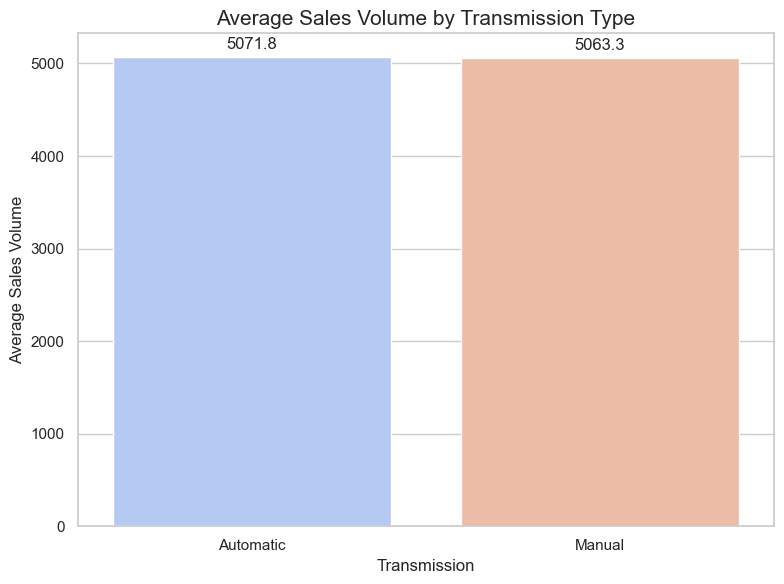

--- Average Sales Volume by Transmission ---
  transmission  sales_volume
0    Automatic   5071.788497
1       Manual   5063.293194


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set visualization theme
sns.set_theme(style="whitegrid")

# 2. Group by transmission and calculate average sales volume
# Based on your data, we expect 2 categories: Automatic and Manual
trans_analysis = df.groupby('transmission')['sales_volume'].mean().sort_values(ascending=False).reset_index()

# 3. Create the bar chart
plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(data=trans_analysis, x='transmission', y='sales_volume', palette='coolwarm')

# 4. Add labels and title in English
plt.title('Average Sales Volume by Transmission Type', fontsize=15)
plt.xlabel('Transmission', fontsize=12)
plt.ylabel('Average Sales Volume', fontsize=12)

# 5. Display exact values on top of bars
for p in bar_plot.patches:
    bar_plot.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.tight_layout()
plt.savefig('sales_by_transmission.png')
plt.show()

# 6. Print numerical summary
print("--- Average Sales Volume by Transmission ---")
print(trans_analysis)